# Using Python

Sam Foreman [](https://orcid.org/0000-0002-9981-0876)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2025-08-06

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/00-intro-AI-HPC/3-python/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/00-intro-AI-HPC/3-python/index.qmd)

> **🎯 What you’ll learn**
>
> Python is the language of modern AI, and almost every page after this
> one assumes you can read and write it. This is a **hands-on** warm-up
> — run each cell, change it, run it again. By the end you’ll be
> comfortable with:
>
> - **variables & types** — numbers, strings, booleans
> - **data structures** — lists, dictionaries, and how to loop over them
> - **functions** — packaging logic you can reuse
> - **imports** — pulling in the scientific-Python stack (`numpy`,
>   `matplotlib`, …)
>
> No prior Python needed. If you already know this, skim to the
> [exercises](#exercises).

## 🐚 A little shell first

Before Python, a word on the **shell** — the text prompt you type
commands into on a laptop or a supercomputer login node. You’ll use it
to move around the filesystem, run scripts, and submit jobs. The
essentials:

|       command       | what it does                          |
|:-------------------:|:--------------------------------------|
|        `pwd`        | print working directory (where am I?) |
|        `ls`         | list files here                       |
|       `cd d/`       | change into directory `d/`            |
|       `cat f`       | print the contents of file `f`        |
| `python3 script.py` | run a Python script                   |

You can run shell commands *from inside a notebook* by prefixing them
with `!`. Here’s the Python version we’re running:

In [1]:
!python3 --version

Python 3.14.5

> **📓 Go deeper: the shell**
>
> - [Course overview + the shell · Missing
>   Semester](https://missing.csail.mit.edu/2020/course-shell/)
> - [Shell Tools and Scripting · Missing
>   Semester](https://missing.csail.mit.edu/2020/shell-tools/)

## 🐍 Variables and types

A **variable** is a name bound to a value. Python figures out the type
for you:

In [2]:
n_gpus = 4              # int
learning_rate = 0.001   # float
model_name = "GPT"      # str
is_training = True       # bool

print(n_gpus, learning_rate, model_name, is_training)
print(type(n_gpus), type(learning_rate), type(model_name), type(is_training))

4 0.001 GPT True
<class 'int'> <class 'float'> <class 'str'> <class 'bool'>

Arithmetic and f-strings (string formatting) are the two things you’ll
reach for constantly:

In [3]:
tokens = 1_000_000
seconds = 42.0
throughput = tokens / seconds
print(f"Processed {tokens:,} tokens in {seconds:.1f}s → {throughput:,.0f} tokens/sec")

Processed 1,000,000 tokens in 42.0s → 23,810 tokens/sec

## 📦 Data structures: lists and dicts

A **list** is an ordered, mutable collection. A **dictionary** maps keys
to values. Between them they cover most of what you’ll need:

In [4]:
# a list of layer widths
layers = [784, 256, 128, 10]
print("num layers:", len(layers))
print("first / last:", layers[0], layers[-1])   # negative index counts from the end
layers.append(1)                                 # add to the end
print("after append:", layers)

num layers: 4
first / last: 784 10
after append: [784, 256, 128, 10, 1]

In [5]:
# a dict of hyperparameters
config = {"lr": 0.001, "batch_size": 64, "epochs": 10}
print("learning rate:", config["lr"])
config["optimizer"] = "adam"        # add a new key
for key, value in config.items():   # loop over key/value pairs
    print(f"  {key:12s} = {value}")

learning rate: 0.001
  lr           = 0.001
  batch_size   = 64
  epochs       = 10
  optimizer    = adam

## 🔁 Loops and comprehensions

A `for` loop repeats work. A **list comprehension** is the Pythonic
one-liner for “build a list by transforming another”:

In [6]:
# the long way
squares = []
for x in range(1, 6):
    squares.append(x ** 2)
print("loop:", squares)

# the Pythonic way — same result
squares = [x ** 2 for x in range(1, 6)]
print("comprehension:", squares)

# with a condition
even_squares = [x ** 2 for x in range(1, 11) if x % 2 == 0]
print("even squares:", even_squares)

loop: [1, 4, 9, 16, 25]
comprehension: [1, 4, 9, 16, 25]
even squares: [4, 16, 36, 64, 100]

## 🧰 Functions

A **function** packages logic behind a name so you can reuse it. Define
with `def`, hand back a result with `return`:

In [7]:
def relu(x):
    """Rectified linear unit: max(0, x) — the workhorse activation function."""
    return x if x > 0 else 0.0

for v in [-2.0, -0.5, 0.0, 1.5, 3.0]:
    print(f"relu({v:+.1f}) = {relu(v)}")

relu(-2.0) = 0.0
relu(-0.5) = 0.0
relu(+0.0) = 0.0
relu(+1.5) = 1.5
relu(+3.0) = 3.0

Functions can take **default arguments**, which makes them flexible:

In [8]:
def scale(values, factor=2.0):
    return [v * factor for v in values]

print(scale([1, 2, 3]))          # uses the default factor=2.0
print(scale([1, 2, 3], factor=10))

[2.0, 4.0, 6.0]
[10, 20, 30]

## 📚 Imports: the scientific-Python stack

Real work builds on **libraries**. You pull them in with `import`. The
three you’ll see on nearly every page:

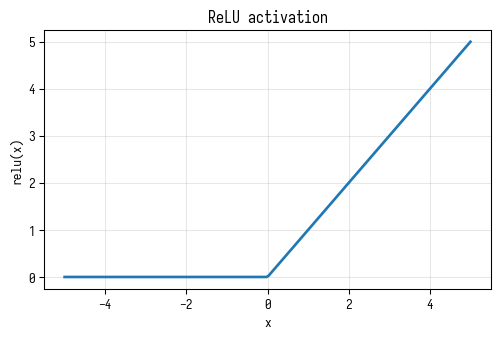

In [9]:
import numpy as np              # fast numerical arrays
import matplotlib.pyplot as plt # plotting
from bootcamp.plotly_theme import apply_mpl_font
apply_mpl_font()                # use the site's Iosevka font in matplotlib figures

# make a smooth curve and plot our relu on it
xs = np.linspace(-5, 5, 200)
ys = np.maximum(0, xs)          # numpy's vectorized relu

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(xs, ys, lw=2)
ax.set_title("ReLU activation")
ax.set_xlabel("x"); ax.set_ylabel("relu(x)")
ax.grid(True, alpha=0.3)
plt.show()

That `np.maximum(0, xs)` applied `relu` to all 200 points **at once** —
no loop. This *vectorized* style is why NumPy is fast, and it’s the
subject of the next page, [**Working with Data**](../4-data/index.qmd).

## Exercises

Try these — each has a hidden solution, but give it a real attempt
first.

> **Exercise 1 — a function**
>
> Write a function `mean(values)` that returns the average of a list of
> numbers, then call it on `[10, 20, 30, 40]` (you should get `25.0`).
>
> > **💡 Solution**
> >
> > ``` python
> > def mean(values):
> >     return sum(values) / len(values)
> >
> > print(mean([10, 20, 30, 40]))
> > ```
> >
> >     25.0

> **Exercise 2 — a comprehension**
>
> Given `words = ["hpc", "gpu", "llm"]`, use a list comprehension to
> build a list of their **uppercased** forms: `["HPC", "GPU", "LLM"]`.
> (Hint: strings have an `.upper()` method.)
>
> > **💡 Solution**
> >
> > ``` python
> > words = ["hpc", "gpu", "llm"]
> > print([w.upper() for w in words])
> > ```
> >
> >     ['HPC', 'GPU', 'LLM']

> **Exercise 3 — dicts + a loop**
>
> You have per-GPU token counts
> `counts = {"gpu0": 120, "gpu1": 95, "gpu2": 130}`. Print the **total**
> across all GPUs and the **name of the busiest** GPU.
>
> > **💡 Solution**
> >
> > ``` python
> > counts = {"gpu0": 120, "gpu1": 95, "gpu2": 130}
> > print("total:", sum(counts.values()))
> > print("busiest:", max(counts, key=counts.get))
> > ```
> >
> >     total: 345
> >     busiest: gpu2

## 🔑 Key takeaways

- Variables are typed automatically; f-strings (`f"{x:.2f}"`) format
  output.
- **Lists** (ordered) and **dicts** (key→value) are your everyday
  containers.
- **Comprehensions** (`[f(x) for x in xs]`) replace many simple loops.
- **Functions** (`def … return`) package reusable logic.
- **`import`** brings in libraries — `numpy` and `matplotlib` above all.

> **📓 Go deeper: Python**
>
> - [The Python Tutorial](https://docs.python.org/3/tutorial/)
> - [A Whirlwind Tour of
>   Python](https://nbviewer.org/github/jakevdp/WhirlwindTourOfPython/blob/master/Index.ipynb)
> - [Python Data Science
>   Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/index.html)
> - [Python Introduction \| Google for
>   Developers](https://developers.google.com/edu/python/introduction)
> - [foundational_hpc_skills/intro_to_python ·
>   olcf](https://github.com/olcf/foundational_hpc_skills/tree/master/intro_to_python)

➡️ **Next:** [Working with Data](../4-data/index.qmd) — NumPy arrays,
pandas, and plotting real data.